# DDoS Auswertung

## 0. Foreplay

### Notes:

instead of polars, the polars-lts-cpu package is used, to run on the old CPU's of the mobi8

### Imports

In [30]:
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pyarrow.parquet as pq

### Global parameters

In [31]:
SERVER_IP = "141.22.28.227"
IPV4_MULTICAST_PREFIX = "224."
IPV6_MULTICAST_PREFIX = "ff0"

PARQUET_FILE = "data/interim/ddos_1/batch_1_1000.parquet"
PARQUET_FOLDER = "data/processed/ddos_1/batch_1_1000/coap/"
PLOT_FOLDER = "plots/batch_1_1000/coap/"

### Read

In [32]:
lf = pl.scan_parquet(PARQUET_FILE).drop("dtls.record.content_type", "dtls.record.version", "dtls.handshake.type")

### Sample

In [33]:
df_sample = lf.limit(100000).collect().sample(5)
df_sample

frame.datetime,frame.len,frame.protocols,ip.src,ip.dst,ip.proto,ip.ttl,ipv6.src,ipv6.dst,ipv6.hlim,udp.srcport,udp.dstport,udp.length,tcp.srcport,tcp.dstport,tcp.len,coap.version,coap.type,coap.code,coap.mid,coap.token,coap.token_len,coap.opt.uri_path,coap.opt.uri_query,coap.opt.block_number,coap.opt.block_mflag,coap.opt.block_size,coap.opt.observe,coap.response_to,coap.response_in,coap.payload_length,source_file
datetime[μs],i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
2025-08-13 15:51:49.758500,1514,"""eth:ethertype:ip:udp:dns""","""103.36.8.114""","""141.22.28.227""","""17""","""52""",null,null,null,"""53""","""38629""",3744,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:50.412338,1490,"""eth:ethertype:ip:udp:snmp""","""81.215.226.19""","""141.22.28.227""","""17""","""51""",null,null,null,"""161""","""56752""",2298,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:50.344938,1506,"""eth:ethertype:ip:data""","""187.236.23.39""","""141.22.28.227""","""17""","""48""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:50.107102,1514,"""eth:ethertype:ip:udp:dns""","""206.188.225.180""","""141.22.28.227""","""17""","""50""",null,null,null,"""53""","""14246""",3783,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:50.353701,818,"""eth:ethertype:ip:data""","""89.91.12.211""","""141.22.28.227""","""17""","""51""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"


## CoAP specific analysis

## Share of CoAP

In [43]:
lf_coap = lf.filter(
    pl.col("coap.version").is_not_null()
)
total_packets = lf.select(pl.len()).collect().item()
coap_packets = lf_coap.select(pl.len()).collect().item()
total_bytes = lf.select(pl.col("frame.len").sum()).collect().item()
coap_bytes = lf_coap.select(pl.col("frame.len").sum()).collect().item()

t_start = lf.select(pl.col("frame.datetime").min()).collect().item()
t_end = lf.select(pl.col("frame.datetime").max()).collect().item()
if t_start and t_end != None:
    duration_s = (t_end - t_start).total_seconds()

avg_len = (
    lf_coap.select(pl.col("frame.len").mean())
    .collect()
    .item()
)
max_len = (
    lf_coap.select(pl.col("frame.len").max())
    .collect()
    .item()
)

print(f"CoAP distribution   : {coap_packets / total_packets:.2f}%")
print(f"All pakets          : {total_packets:>12,}")
print(f"CoAP packets        : {coap_packets:>12,}")
print(f"All bytes           : {total_bytes:>12,}  ({total_bytes/1e6:.1f} MB)")
print(f"CoAP bytes          : {coap_bytes:>12,}  ({coap_bytes/1e6:.1f} MB)")
print(f"Ø CoAP Packetrate   : {total_packets/duration_s:>10,.1f} pkt/s")
print(f"Ø CoAP Bitrate      : {total_bytes*8/duration_s/1e6:>10,.1f} Mbit/s")
print(f"Average packet size : {avg_len:.1f} bytes")
print(f"Maximum packet size : {max_len} bytes")

CoAP distribution   : 0.07%
All pakets          :  696,340,178
CoAP packets        :   51,418,885
All bytes           : 801,727,874,184  (801727.9 MB)
CoAP bytes          : 68,581,946,168  (68581.9 MB)
Ø CoAP Packetrate   :  101,199.1 pkt/s
Ø CoAP Bitrate      :      932.1 Mbit/s
Average packet size : 1333.8 bytes
Maximum packet size : 1514 bytes


In [35]:
lf_coap_no_udp = lf_coap.filter(
    (pl.col("coap.version").is_not_null()) & (pl.col("ip.proto") != "17")
)

### IP Protocol Distribution

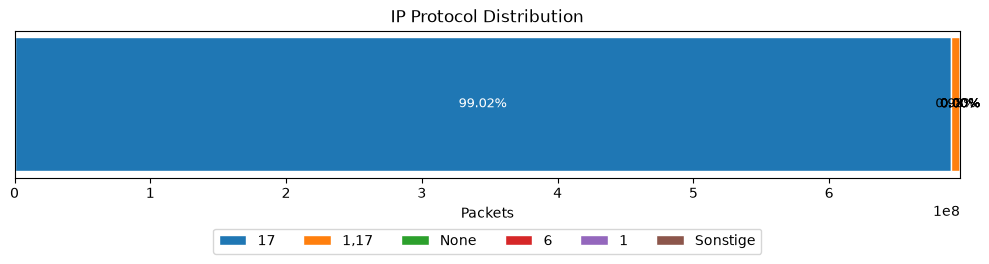

In [36]:
df = (
    lf.group_by("ip.proto")
    .agg(pl.len().alias("count"))
    .collect()
    .sort("count", descending=True)
)
labels = [str(x) for x in df["ip.proto"].to_list()]
values = df["count"].to_list()

# top_n_plus_other erwartet Spaltennamen, daher hier manuell mit String-Labels
total = sum(values)
top_labels, top_values = labels[:5], values[:5]
rest_sum = sum(values[5:])
if rest_sum > 0:
    top_labels.append("Sonstige")
    top_values.append(rest_sum)

del df

colors = plt.cm.tab10.colors[: len(top_labels)]

fig, ax = plt.subplots(figsize=(10, 3))

left = 0
for label, value, color in zip(top_labels, top_values, colors):
    pct = value / total * 100
    ax.barh(0, value, left=left, color=color, edgecolor="white", label=label)
    ax.text(
        left + value / 2, 0, f"{pct:.2f}%",
        ha="center", va="center", fontsize=9,
        color="white" if pct > 3 else "black",
    )
    left += value

ax.set_xlim(0, total)
ax.set_yticks([])
ax.set_xlabel("Packets")
ax.set_title("IP Protocol Distribution")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=len(top_labels))

plt.tight_layout()
plt.savefig(PLOT_FOLDER + "ip_proto_distr")
plt.show()
plt.close(fig)

### Top CoAP Talker

In [40]:
df_by_ip_src = (
    lf_coap.group_by("ip.src")
    .agg([
        pl.len().alias("packets"),
        pl.col("frame.len").sum().alias("bytes"),
    ])
    .sort("bytes", descending=True)
    .head(20)
    .collect()
)

labels = df_by_ip_src["ip.src"].to_list()
bytes_vals = df_by_ip_src["bytes"].to_list()
packets_vals = df_by_ip_src["packets"].to_list()

colors = cm.tab20.colors[: len(labels)]

fig, ax = plt.subplots(figsize=(10, 8))

y_pos = range(len(labels))
ax.barh(y_pos, bytes_vals, color=colors)

for i, (b, p) in enumerate(zip(bytes_vals, packets_vals)):
    ax.text(b * 1.01, i, f"{b:,} B / {p:,} pkts", va="center", fontsize=8)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Bytes")
ax.set_title("Top 20 Source IPs by Bytes talking CoAP")

plt.tight_layout()
plt.savefig(PLOT_FOLDER + "coap_top20_ip_src.png", dpi=150, bbox_inches="tight")
plt.close(fig)

del df_by_ip_src, labels, bytes_vals, packets_vals

### Packets Size

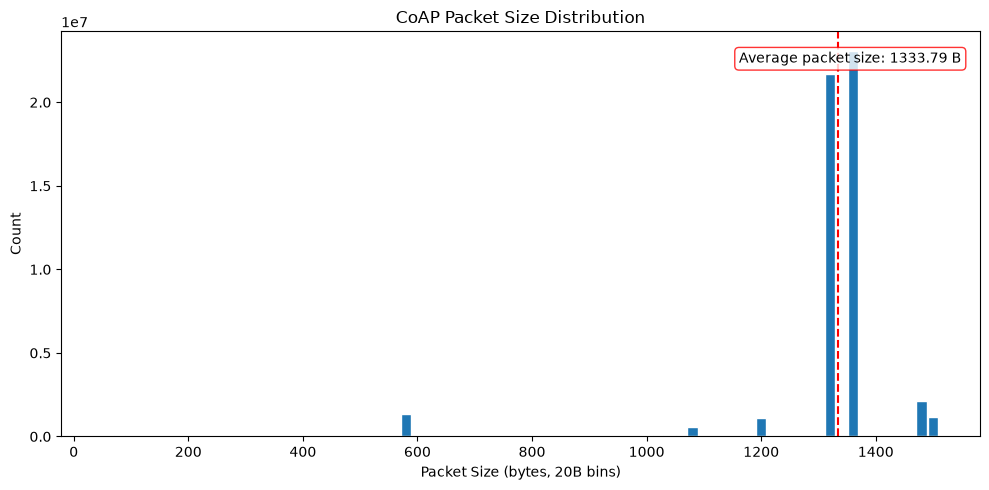

In [41]:
avg_packet_size = lf_coap.select(pl.col("frame.len").mean()).collect().item()

bins_df = (
    lf_coap.select(
        ((pl.col("frame.len") // 20) * 20).alias("bin")
    )
    .group_by("bin")
    .agg(pl.len().alias("count"))
    .sort("bin")
    .collect()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bins_df["bin"], bins_df["count"], width=18, color="tab:blue", edgecolor="white")
ax.axvline(avg_packet_size, color="red", linestyle="--", linewidth=1.5)

ax.text(
    0.98, 0.95,
    f"Average packet size: {avg_packet_size:.2f} B",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="red", alpha=0.8),
)

ax.set_xlabel("Packet Size (bytes, 20B bins)")
ax.set_ylabel("Count")
ax.set_title("CoAP Packet Size Distribution")

plt.tight_layout()
Path(PLOT_FOLDER).mkdir(parents=True, exist_ok=True)
plt.savefig(Path(PLOT_FOLDER) / "coap_packet_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Mapping to Simple, Observe and Group Requests and Group + Observe

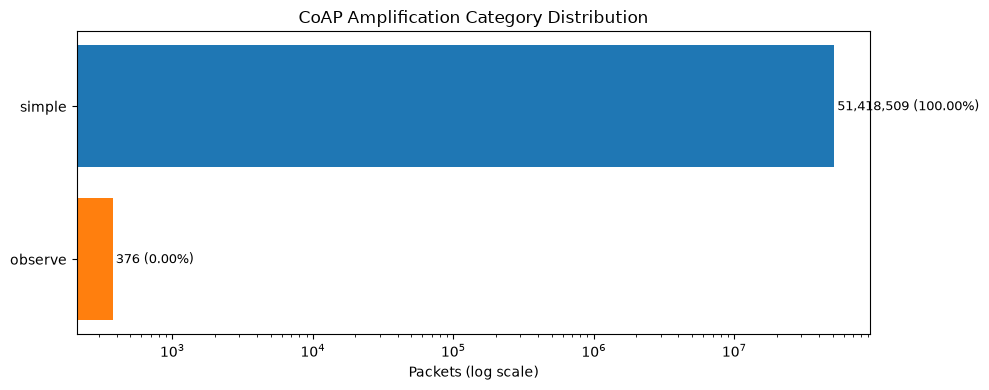

In [38]:
is_group_request = (
    pl.col("ip.dst").str.starts_with(IPV4_MULTICAST_PREFIX)
    | pl.col("ipv6.dst").str.starts_with(IPV6_MULTICAST_PREFIX)
)
has_observe = pl.col("coap.opt.observe").is_not_null()

lf_coap_classified = lf_coap.with_columns(
    pl.when(is_group_request & has_observe)
    .then(pl.lit("group_request_with_observe"))
    .when(is_group_request)
    .then(pl.lit("group_request"))
    .when(has_observe)
    .then(pl.lit("observe"))
    .otherwise(pl.lit("simple"))
    .alias("amplification_category")
)

df_category_counts = (
    lf_coap_classified.group_by("amplification_category")
    .agg(pl.len().alias("count"))
    .collect()
    .sort("count", descending=True)
)

# plotting
labels = df_category_counts["amplification_category"].to_list()
values = df_category_counts["count"].to_list()
total = sum(values)

colors = plt.cm.tab10.colors[: len(labels)]

fig, ax = plt.subplots(figsize=(10, 4))

y_pos = range(len(labels))
ax.barh(y_pos, values, color=colors)
for i, v in enumerate(values):
    pct = v / total * 100
    ax.text(v * 1.05, i, f"{v:,} ({pct:.2f}%)", va="center", fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Packets (log scale)")
ax.set_title("CoAP Amplification Category Distribution")

plt.tight_layout()
Path(PLOT_FOLDER).mkdir(parents=True, exist_ok=True)
plt.savefig(Path(PLOT_FOLDER) / "amplification_category_bar.png", dpi=150, bbox_inches="tight")
plt.show()